In [2]:
# @title
# Code 1: Training and saving for communicating MARL, including algorithms 1 and 2

ALL_SEEDS = [5, 20, 24]

RANDOM_SEED = ALL_SEEDS[0]
import numpy as np
np.random.seed(RANDOM_SEED)
import random
random.seed(RANDOM_SEED)
import pickle
import math
import matplotlib.pyplot as plt
import matplotlib.animation as animation

try:
    import pettingzoo
    from pettingzoo.utils import parallel_to_aec, aec_to_parallel
    from pettingzoo.test import parallel_api_test
    import pygame
    from gymnasium import spaces
    from IPython.display import display, Image
    import imageio
    import os
    os.environ["SDL_VIDEODRIVER"] = "dummy"
except ImportError:
    print("Installing PettingZoo, Pygame, and imageio...")
    !pip install pettingzoo[classic] pygame imageio gymnasium > /dev/null 2>&1
    import pettingzoo
    from pettingzoo.utils import parallel_to_aec, aec_to_parallel
    from pettingzoo.test import parallel_api_test
    import pygame
    from gymnasium import spaces
    from IPython.display import display, Image
    import imageio
    import os
    os.environ["SDL_VIDEODRIVER"] = "dummy"
    print("Installation complete.")


# -----------------------------
# Doubly-Stochastic Matrix Class
# -----------------------------
class NormalizedRandomMatrix:
    def __init__(self, n_rows, n_cols):
        if n_rows != n_cols:
            raise ValueError("Doubly-stochastic matrices must be square.")
        self.n_rows = n_rows
        self.n_cols = n_cols

    def generate(self, iterations=20):
        matrix = np.random.rand(self.n_rows, self.n_cols)
        for _ in range(iterations):
            col_sums = matrix.sum(axis=0, keepdims=True)
            col_sums[col_sums == 0] = 1
            matrix = matrix / col_sums

            row_sums = matrix.sum(axis=1, keepdims=True)
            row_sums[row_sums == 0] = 1
            matrix = matrix / row_sums
        return matrix


# -----------------------------
# Grid World Configuration
# -----------------------------
NUM_AGENTS = 4
GRID_ROWS = 6
GRID_COLS = 6
NUM_CELLS = GRID_ROWS * GRID_COLS

AGENT_ACTIONS = {
    'UP': 0,
    'DOWN': 1,
    'LEFT': 2,
    'RIGHT': 3,
    'STAY': 4,
    'RESET_RM_STAY': 5
}
NUM_ACTIONS_PER_AGENT = len(AGENT_ACTIONS)

ACTION_EFFECTS = {
    AGENT_ACTIONS['UP']: (-1, 0),
    AGENT_ACTIONS['DOWN']: (1, 0),
    AGENT_ACTIONS['LEFT']: (0, -1),
    AGENT_ACTIONS['RIGHT']: (0, 1),
    AGENT_ACTIONS['STAY']: (0, 0),
    AGENT_ACTIONS['RESET_RM_STAY']: (0, 0)
}

NUM_JOINT_ACTIONS = NUM_ACTIONS_PER_AGENT ** NUM_AGENTS

SHAPING_TARGET_WEIGHT = 1.0
SHAPED_REWARD_COEFFICIENT = 0.5


def get_flat_pos(row, col):
    return row * GRID_COLS + col


def get_row_col(flat_pos):
    return flat_pos // GRID_COLS, flat_pos % GRID_COLS


START_POSITIONS_LIST = [21, 15, 14, 20]

AGENT_RCH1_CELLS = {
    0: 0,
    1: 30,
    2: 35,
    3: 5,
}

AGENT_RCH2_CELLS = {
    0: 5,
    1: 0,
    2: 30,
    3: 35,
}

SAFE_TARGET_CELLS = set(AGENT_RCH1_CELLS.values()) | set(AGENT_RCH2_CELLS.values())


def get_manhattan_distance(pos1_flat, pos2_flat):
    r1, c1 = get_row_col(pos1_flat)
    r2, c2 = get_row_col(pos2_flat)
    return abs(r1 - r2) + abs(c1 - c2)


def decode_env_state(env_state_idx):
    positions = []
    temp_idx = env_state_idx
    for _ in range(NUM_AGENTS):
        positions.append(temp_idx % NUM_CELLS)
        temp_idx //= NUM_CELLS
    return positions[::-1]


def encode_env_state(positions_list):
    env_state_idx = 0
    for pos in positions_list:
        env_state_idx = env_state_idx * NUM_CELLS + pos
    return env_state_idx


def decode_joint_action(joint_action_idx):
    actions = []
    temp_idx = joint_action_idx
    for _ in range(NUM_AGENTS):
        actions.append(temp_idx % NUM_ACTIONS_PER_AGENT)
        temp_idx //= NUM_ACTIONS_PER_AGENT
    return actions[::-1]


def get_next_cell_pos(current_flat_pos, action_idx):
    r_curr, c_curr = get_row_col(current_flat_pos)
    dr, dc = ACTION_EFFECTS.get(action_idx, (0, 0))
    r_next, c_next = r_curr + dr, c_curr + dc

    if not (0 <= r_next < GRID_ROWS and 0 <= c_next < GRID_COLS):
        return current_flat_pos

    return get_flat_pos(r_next, c_next)


def get_non_colliding_initial_state():
    if len(START_POSITIONS_LIST) != NUM_AGENTS:
        raise ValueError("The number of starting positions does not match NUM_AGENTS.")
    return encode_env_state(START_POSITIONS_LIST)


# -----------------------------
# State Feature Engineering
# -----------------------------
RM_STATES = None
RM_STATE_MAP = None
NUM_RM_STATES = None


def get_state_features(env_state_idx, agent_index, rm_state):
    all_positions = decode_env_state(env_state_idx)
    my_pos = all_positions[agent_index]
    other_positions = [pos for i, pos in enumerate(all_positions) if i != agent_index]

    features = []
    my_r, my_c = get_row_col(my_pos)
    max_dist = (GRID_ROWS - 1) + (GRID_COLS - 1)

    features.extend([my_r / (GRID_ROWS - 1), my_c / (GRID_COLS - 1)])

    for pos_flat in other_positions:
        r, c = get_row_col(pos_flat)
        features.extend([r / (GRID_ROWS - 1), c / (GRID_COLS - 1)])

    dist_to_rch1 = get_manhattan_distance(my_pos, AGENT_RCH1_CELLS[agent_index])
    dist_to_rch2 = get_manhattan_distance(my_pos, AGENT_RCH2_CELLS[agent_index])

    features.append(dist_to_rch1 / max_dist if max_dist > 0 else 0)
    features.append(dist_to_rch2 / max_dist if max_dist > 0 else 0)

    for other_pos in other_positions:
        dist_to_other = get_manhattan_distance(my_pos, other_pos)
        features.append(dist_to_other / max_dist if max_dist > 0 else 0)

    is_on_edge = (
        my_r == 0 or
        my_r == GRID_ROWS - 1 or
        my_c == 0 or
        my_c == GRID_COLS - 1
    )

    is_in_corner = (
        (my_r == 0 or my_r == GRID_ROWS - 1) and
        (my_c == 0 or my_c == GRID_COLS - 1)
    )

    features.extend([1.0 if is_on_edge else 0.0, 1.0 if is_in_corner else 0.0])

    rm_state_one_hot = np.zeros(NUM_RM_STATES)
    if rm_state in RM_STATE_MAP:
        rm_state_one_hot[RM_STATE_MAP[rm_state]] = 1.0

    features.extend(rm_state_one_hot)
    features.append(1.0)  # Bias term

    return np.array(features)


def get_composite_shaped_reward(
    current_env_state_idx,
    next_env_state_idx,
    agent_index,
    current_rm_state,
    next_rm_state
):
    current_positions = decode_env_state(current_env_state_idx)
    next_positions = decode_env_state(next_env_state_idx)

    def calculate_potential(positions, agent_idx, rm_state):
        my_pos = positions[agent_idx]
        agent_rch1_pos = AGENT_RCH1_CELLS[agent_idx]
        agent_rch2_pos = AGENT_RCH2_CELLS[agent_idx]

        if rm_state == 'q_1':
            shaping_target_pos = agent_rch2_pos
        else:
            shaping_target_pos = agent_rch1_pos

        return -SHAPING_TARGET_WEIGHT * get_manhattan_distance(my_pos, shaping_target_pos)

    potential_current = calculate_potential(
        current_positions,
        agent_index,
        current_rm_state
    )

    potential_next = calculate_potential(
        next_positions,
        agent_index,
        next_rm_state
    )

    return potential_next - potential_current


# -----------------------------
# Probabilistic Actions and Collision Avoidance
# -----------------------------
PROBABILISTIC_ACTION_CONFIG = {
    AGENT_ACTIONS['UP']: [
        (AGENT_ACTIONS['UP'], 0.8),
        (AGENT_ACTIONS['LEFT'], 0.1),
        (AGENT_ACTIONS['RIGHT'], 0.1)
    ],
    AGENT_ACTIONS['DOWN']: [
        (AGENT_ACTIONS['DOWN'], 0.8),
        (AGENT_ACTIONS['LEFT'], 0.1),
        (AGENT_ACTIONS['RIGHT'], 0.1)
    ],
    AGENT_ACTIONS['LEFT']: [
        (AGENT_ACTIONS['LEFT'], 0.8),
        (AGENT_ACTIONS['UP'], 0.1),
        (AGENT_ACTIONS['DOWN'], 0.1)
    ],
    AGENT_ACTIONS['RIGHT']: [
        (AGENT_ACTIONS['RIGHT'], 0.8),
        (AGENT_ACTIONS['UP'], 0.1),
        (AGENT_ACTIONS['DOWN'], 0.1)
    ],
    AGENT_ACTIONS['STAY']: [
        (AGENT_ACTIONS['STAY'], 1.0)
    ],
    AGENT_ACTIONS['RESET_RM_STAY']: [
        (AGENT_ACTIONS['RESET_RM_STAY'], 1.0)
    ]
}


def get_probabilistic_outcomes(action_idx):
    return PROBABILISTIC_ACTION_CONFIG.get(action_idx, [(action_idx, 1.0)])


def _calculate_next_state_with_collision_avoidance(current_s_idx, actual_actions):
    current_positions = decode_env_state(current_s_idx)

    potential_next_positions = [
        get_next_cell_pos(current_positions[i], actual_actions[i])
        for i in range(NUM_AGENTS)
    ]

    final_positions = list(current_positions)
    agent_indices = list(range(NUM_AGENTS))
    colliding_agents = set()

    for i in agent_indices:
        if i in colliding_agents:
            continue

        for j in range(i + 1, NUM_AGENTS):
            if j in colliding_agents:
                continue

            if potential_next_positions[i] == potential_next_positions[j]:
                destination_cell = potential_next_positions[i]

                if destination_cell not in SAFE_TARGET_CELLS:
                    colliding_agents.add(i)
                    colliding_agents.add(j)

    for i in agent_indices:
        if i not in colliding_agents:
            final_positions[i] = potential_next_positions[i]

    return encode_env_state(final_positions)


def sample_next_state(current_s_idx, joint_action_indices):
    actual_actions = []

    for i in range(NUM_AGENTS):
        outcomes = get_probabilistic_outcomes(joint_action_indices[i])
        actions, probs = zip(*outcomes)
        actual_actions.append(np.random.choice(actions, p=probs))

    return _calculate_next_state_with_collision_avoidance(current_s_idx, actual_actions)


def get_label(env_state_idx, agent_index):
    positions = decode_env_state(env_state_idx)

    is_rch1 = (positions[agent_index] == AGENT_RCH1_CELLS[agent_index])
    is_rch2 = (positions[agent_index] == AGENT_RCH2_CELLS[agent_index])

    rch1_str = "(rch1)" if is_rch1 else "(!rch1)"
    rch2_str = "(rch2)" if is_rch2 else "(!rch2)"

    return f"{rch1_str}&{rch2_str}"


# -----------------------------
# Reward Machine and RL Utilities
# -----------------------------
class RewardMachine:
    def __init__(self, initial_state, states, transitions):
        self.initial_state = initial_state
        self.states = states
        self.transitions = {
            key: (value[0][0], int(value[0][1]))
            for key, value in transitions.items()
        }

    def step(self, current_rm_state, symbol):
        return self.transitions.get(
            (current_rm_state, symbol),
            (current_rm_state, 0.0)
        )


def softmax(x):
    exp_x = np.exp(x - np.max(x, axis=-1, keepdims=True))
    return exp_x / np.sum(exp_x, axis=-1, keepdims=True)


# -----------------------------
# PettingZoo Environment
# -----------------------------
class GridWorldEnv(pettingzoo.ParallelEnv):
    metadata = {
        "render_modes": ["rgb_array"],
        "name": "gridworld-v0"
    }

    def __init__(self, render_mode="rgb_array"):
        self.agents = [f"agent_{i+1}" for i in range(NUM_AGENTS)]
        self.possible_agents = self.agents[:]
        self.render_mode = render_mode

        self.num_env_states = NUM_CELLS ** NUM_AGENTS
        self.current_env_state = 0

        self.observation_space = {
            a: spaces.Discrete(self.num_env_states)
            for a in self.agents
        }

        self.action_space = {
            a: spaces.Discrete(NUM_ACTIONS_PER_AGENT)
            for a in self.agents
        }

        self.screen_width = 400
        self.screen_height = 400
        self.screen = None

        colors = [
            plt.cm.viridis(i / max(1, NUM_AGENTS - 1))
            for i in range(NUM_AGENTS)
        ]

        self.agent_colors = [
            (int(r * 255), int(g * 255), int(b * 255))
            for r, g, b, a in colors
        ]

    def reset(self, seed=None, options=None):
        if seed is not None:
            np.random.seed(seed)
            random.seed(seed)

        self.current_env_state = get_non_colliding_initial_state()
        return self._get_obs(), {a: {} for a in self.agents}

    def _get_obs(self):
        return {a: self.current_env_state for a in self.agents}

    def step(self, actions):
        actual_actions = []

        for i, agent_id in enumerate(self.agents):
            policy_action = actions[agent_id]
            outcomes = get_probabilistic_outcomes(policy_action)
            action_choices, probs = zip(*outcomes)
            actual_actions.append(np.random.choice(action_choices, p=probs))

        self.current_env_state = _calculate_next_state_with_collision_avoidance(
            self.current_env_state,
            actual_actions
        )

        return (
            self._get_obs(),
            {a: 0 for a in self.agents},
            {a: False for a in self.agents},
            {a: False for a in self.agents},
            {a: {} for a in self.agents}
        )

    def render(self):
        if self.screen is None:
            pygame.init()
            self.screen = pygame.Surface((self.screen_width, self.screen_height))

        cell_w = self.screen_width / GRID_COLS
        cell_h = self.screen_height / GRID_ROWS

        self.screen.fill((255, 255, 255))

        indicator_w = cell_w / 2
        indicator_h = cell_h / 2

        quadrant_offsets = [
            (0, 0),
            (indicator_w, 0),
            (0, indicator_h),
            (indicator_w, indicator_h)
        ]

        for i in range(NUM_AGENTS):
            agent_color = self.agent_colors[i]
            offset_x, offset_y = quadrant_offsets[i]

            rch1_flat = AGENT_RCH1_CELLS[i]
            r1, c1 = get_row_col(rch1_flat)

            rch1_color = (
                min(255, agent_color[0] + 120),
                min(255, agent_color[1] + 120),
                min(255, agent_color[2] + 120)
            )

            indicator_x1 = c1 * cell_w + offset_x
            indicator_y1 = r1 * cell_h + offset_y

            pygame.draw.rect(
                self.screen,
                rch1_color,
                (indicator_x1, indicator_y1, indicator_w, indicator_h)
            )

            rch2_flat = AGENT_RCH2_CELLS[i]
            r2, c2 = get_row_col(rch2_flat)
            rch2_color = agent_color

            indicator_x2 = c2 * cell_w + offset_x
            indicator_y2 = r2 * cell_h + offset_y

            pygame.draw.rect(
                self.screen,
                rch2_color,
                (indicator_x2, indicator_y2, indicator_w, indicator_h)
            )

        for r in range(GRID_ROWS):
            for c in range(GRID_COLS):
                pygame.draw.rect(
                    self.screen,
                    (128, 128, 128),
                    (c * cell_w, r * cell_h, cell_w, cell_h),
                    1
                )

        for i, pos_flat in enumerate(decode_env_state(self.current_env_state)):
            r, c = get_row_col(pos_flat)

            pygame.draw.circle(
                self.screen,
                self.agent_colors[i],
                (c * cell_w + cell_w / 2, r * cell_h + cell_h / 2),
                min(cell_w, cell_h) / 3
            )

        if self.render_mode == "rgb_array":
            return np.transpose(
                np.array(pygame.surfarray.pixels3d(self.screen)),
                axes=(1, 0, 2)
            )

    def close(self):
        if self.screen:
            pygame.quit()
            self.screen = None


# -----------------------------
# Main Adaptive Training Loop
# Algorithm 1 inside Algorithm 2
# -----------------------------
def run_experiment(seed_index, total_training_steps=80000):
    """
    Runs communicating MARL training with Algorithm 2 adaptive penalty selection.
    """
    np.random.seed(RANDOM_SEED)
    random.seed(RANDOM_SEED)

    global RM_STATES, RM_STATE_MAP, NUM_RM_STATES

    num_agents = NUM_AGENTS

    # --------------------------------------------------
    # Algorithm 2 hyperparameters
    # --------------------------------------------------
    K_max = 5
    gamma = 2.0
    H_k = 5000
    tau = 0.015

    current_penalty = -0.5

    # --------------------------------------------------
    # Algorithm 1 hyperparameters
    # --------------------------------------------------
    alpha_exponent_critic = 0.70
    alpha_exponent_actor = 0.85

    initial_entropy_coeff = 0.15
    final_entropy_coeff = 0.0001
    annealing_steps = int(total_training_steps * 0.9)

    # --------------------------------------------------
    # Reward Machine Definition
    # --------------------------------------------------
    rm = RewardMachine(
        'q_0',
        {'q_0', 'q_1'},
        {
            ('q_0', "(rch1)&(rch2)"): [('q_0', True)],
            ('q_0', "(!rch1)&(rch2)"): [('q_0', False)],
            ('q_0', "(rch1)&(!rch2)"): [('q_1', False)],
            ('q_0', "(!rch1)&(!rch2)"): [('q_0', False)],
            ('q_1', "(rch1)&(rch2)"): [('q_0', True)],
            ('q_1', "(!rch1)&(rch2)"): [('q_0', True)],
            ('q_1', "(rch1)&(!rch2)"): [('q_1', False)],
            ('q_1', "(!rch1)&(!rch2)"): [('q_1', False)],
        }
    )

    RM_STATES = sorted(list(rm.states))
    RM_STATE_MAP = {state: i for i, state in enumerate(RM_STATES)}
    NUM_RM_STATES = len(RM_STATES)

    # --------------------------------------------------
    # Communicating MARL setup
    # --------------------------------------------------
    num_base_features = 2 + (num_agents - 1) * 2 + 2 + (num_agents - 1) + 2
    num_features = num_base_features + NUM_RM_STATES + 1

    # Fully connected doubly stochastic communication matrix
    W = np.full((num_agents, num_agents), 1 / num_agents)

    policy_tracking_state_idx = 100
    sample_interval = 20000

    # Final variables to keep after outer loop finishes
    final_actor_weights = None
    final_critic_weights = None
    final_rhos = None
    final_steps_history = None
    final_overall_average_reward_history = None
    final_successful_satisfactions_history = None
    final_reset_action_counts_history = None
    final_policy_history_at_specific_state = None
    final_policy_sampling_steps = None
    final_training_frames = []

    # Track outer-loop evaluation histories
    outer_eval_accept_histories = []

    # ==============================================================
    # Algorithm 2 outer loop
    # ==============================================================
    for k in range(K_max):
        print(f"\n{'='*20} OUTER ITERATION {k+1}/{K_max} {'='*20}")
        print(f"Current penalty upper-bound value: {current_penalty}")

        # Reinitialize actor, critic, and rho for each outer iteration
        actor_weights = [
            np.random.randn(num_features, NUM_ACTIONS_PER_AGENT) * 0.1
            for _ in range(num_agents)
        ]

        critic_weights = [
            np.zeros(num_features)
            for _ in range(num_agents)
        ]

        rhos = [0.0 for _ in range(num_agents)]
        rm_states = [rm.initial_state for _ in range(num_agents)]
        cumulative_rewards = [0.0 for _ in range(num_agents)]

        steps_history = []
        overall_average_reward_history = []

        policy_sampling_steps = []
        policy_history_at_specific_state = [[] for _ in range(num_agents)]

        count_successful_satisfactions_total = 0
        successful_satisfactions_history = []

        count_reset_actions_total = 0
        reset_action_counts_history = []

        training_frames = []
        render_interval = 500
        render_env = GridWorldEnv()

        current_env_state = get_non_colliding_initial_state()

        # ===========================================================
        # Algorithm 1 inner training loop
        # ===========================================================
        for step in range(total_training_steps):
            t = step + 1.0

            alpha_critic = 1.0 / (t ** alpha_exponent_critic)
            alpha_actor = 1.0 / (t ** alpha_exponent_actor)

            if step < annealing_steps:
                current_entropy_coeff = (
                    initial_entropy_coeff -
                    (initial_entropy_coeff - final_entropy_coeff) *
                    (step / annealing_steps)
                )
            else:
                current_entropy_coeff = final_entropy_coeff

            actions_chosen = []
            action_probs = []

            for i in range(num_agents):
                features = get_state_features(
                    current_env_state,
                    i,
                    rm_states[i]
                )

                logits = np.dot(features, actor_weights[i])
                probs = softmax(logits)

                action_probs.append(probs)
                actions_chosen.append(
                    np.random.choice(NUM_ACTIONS_PER_AGENT, p=probs)
                )

            reset_count_this_step = actions_chosen.count(
                AGENT_ACTIONS['RESET_RM_STAY']
            )

            count_reset_actions_total += reset_count_this_step
            reset_action_counts_history.append(count_reset_actions_total)

            next_env_state = sample_next_state(
                current_env_state,
                actions_chosen
            )

            labels = [
                get_label(next_env_state, i)
                for i in range(num_agents)
            ]

            rm_rewards = [0.0] * num_agents
            next_rm_states = [None] * num_agents

            for i in range(num_agents):
                if actions_chosen[i] == AGENT_ACTIONS['RESET_RM_STAY']:
                    next_rm_states[i] = rm.initial_state
                    rm_rewards[i] = current_penalty
                else:
                    next_rm, r = rm.step(rm_states[i], labels[i])

                    if r > 0:
                        count_successful_satisfactions_total += 1

                    next_rm_states[i] = next_rm
                    rm_rewards[i] = float(r)

            for i in range(num_agents):
                current_features = get_state_features(
                    current_env_state,
                    i,
                    rm_states[i]
                )

                next_features = get_state_features(
                    next_env_state,
                    i,
                    next_rm_states[i]
                )

                v_curr = np.dot(current_features, critic_weights[i])
                v_next = np.dot(next_features, critic_weights[i])

                delta_critic = rm_rewards[i] - rhos[i] + v_next - v_curr

                critic_weights[i] += alpha_critic * delta_critic * current_features
                rhos[i] += alpha_critic * delta_critic

                shaped_reward_val = get_composite_shaped_reward(
                    current_env_state,
                    next_env_state,
                    i,
                    rm_states[i],
                    next_rm_states[i]
                )

                probs = action_probs[i]
                entropy = -np.sum(probs * np.log(probs + 1e-8))

                delta_actor = (
                    delta_critic +
                    SHAPED_REWARD_COEFFICIENT * shaped_reward_val +
                    current_entropy_coeff * entropy
                )

                grad_log_policy = -np.outer(current_features, action_probs[i])
                grad_log_policy[:, actions_chosen[i]] += current_features

                actor_weights[i] += alpha_actor * delta_actor * grad_log_policy

            # Communication/consensus step for communicating case
            critic_weights = [
                sum(W[i, j] * c for j, c in enumerate(critic_weights))
                for i in range(num_agents)
            ]

            rhos = [
                sum(W[i, j] * r for j, r in enumerate(rhos))
                for i in range(num_agents)
            ]

            current_env_state = next_env_state
            rm_states = next_rm_states

            steps_history.append(step)

            for i in range(num_agents):
                cumulative_rewards[i] += rm_rewards[i]

            overall_average_reward_history.append(
                np.mean([cr / (step + 1) for cr in cumulative_rewards])
            )

            if step > 0 and (
                step % sample_interval == 0 or
                step == total_training_steps - 1
            ):
                if policy_tracking_state_idx < NUM_CELLS ** NUM_AGENTS:
                    policy_sampling_steps.append(step)

                    for i in range(num_agents):
                        features = get_state_features(
                            policy_tracking_state_idx,
                            i,
                            'q_0'
                        )

                        policy_history_at_specific_state[i].append(
                            softmax(np.dot(features, actor_weights[i]))
                        )

            successful_satisfactions_history.append(
                count_successful_satisfactions_total
            )

            if step % render_interval == 0:
                render_env.current_env_state = current_env_state
                training_frames.append(render_env.render())

        render_env.close()

        print(f"Inner training completed for outer iteration {k+1}.")

        # Store current iteration as final candidate
        final_actor_weights = actor_weights
        final_critic_weights = critic_weights
        final_rhos = rhos
        final_steps_history = steps_history
        final_overall_average_reward_history = overall_average_reward_history
        final_successful_satisfactions_history = successful_satisfactions_history
        final_reset_action_counts_history = reset_action_counts_history
        final_policy_history_at_specific_state = policy_history_at_specific_state
        final_policy_sampling_steps = policy_sampling_steps
        final_training_frames = training_frames

        # ===========================================================
        # Evaluate empirical reset frequency for Algorithm 2
        # ===========================================================
        print(f"\nEvaluating empirical reset frequency for {H_k} steps...")

        eval_env = GridWorldEnv()
        eval_obs, _ = eval_env.reset(seed=RANDOM_SEED + k + 1000)

        eval_rm_states = [rm.initial_state for _ in range(num_agents)]
        reset_count_eval = 0
        accept_count_eval = 0
        eval_accept_history_k = []
        evaluation_temperature = 0.9

        for step in range(H_k):
            actions_dict = {}
            current_s_idx = eval_obs["agent_1"]

            for i in range(num_agents):
                agent_id_str = f"agent_{i+1}"

                features = get_state_features(
                    current_s_idx,
                    i,
                    eval_rm_states[i]
                )

                logits = np.dot(features, actor_weights[i])
                temp_adjusted_logits = logits / evaluation_temperature
                action_probabilities = softmax(temp_adjusted_logits)

                actions_dict[agent_id_str] = np.random.choice(
                    NUM_ACTIONS_PER_AGENT,
                    p=action_probabilities
                )

            eval_obs, _, _, _, _ = eval_env.step(actions_dict)
            next_s_idx = eval_obs["agent_1"]

            labels = [
                get_label(next_s_idx, i)
                for i in range(num_agents)
            ]

            for i in range(num_agents):
                agent_id_str = f"agent_{i+1}"

                if actions_dict[agent_id_str] == AGENT_ACTIONS['RESET_RM_STAY']:
                    reset_count_eval += 1
                    eval_rm_states[i] = rm.initial_state
                else:
                    next_rm, r = rm.step(eval_rm_states[i], labels[i])
                    eval_rm_states[i] = next_rm
                    if r > 0:
                        accept_count_eval += 1

            eval_accept_history_k.append(accept_count_eval)

        eval_env.close()

        # Save this iteration's evaluation history
        outer_eval_accept_histories.append(eval_accept_history_k)

        p_hat = reset_count_eval / (H_k * num_agents)

        print(f"Empirical reset frequency p_hat: {p_hat:.6f}")
        print(f"Tolerance tau: {tau}")

        if p_hat <= tau:
            print("Tolerance satisfied. Terminating Algorithm 2 outer loop.")
            break
        else:
            print("Tolerance exceeded. Increasing penalty magnitude.")
            current_penalty *= gamma

            if k == K_max - 1:
                print("Maximum outer iterations reached. Proceeding with final policy.")

    # ==============================================================
    # Restore final trained variables
    # ==============================================================
    actor_weights = final_actor_weights
    critic_weights = final_critic_weights
    rhos = final_rhos
    steps_history = final_steps_history
    overall_average_reward_history = final_overall_average_reward_history
    successful_satisfactions_history = final_successful_satisfactions_history
    reset_action_counts_history = final_reset_action_counts_history
    policy_history_at_specific_state = final_policy_history_at_specific_state
    policy_sampling_steps = final_policy_sampling_steps
    training_frames = final_training_frames

    # ==============================================================
    # Save training animation
    # ==============================================================
    if training_frames:
        gif_filename = f'training_animation_communicating_seed_{RANDOM_SEED}.gif'
        print(f"\nSaving training animation to '{gif_filename}'...")
        imageio.mimsave(gif_filename, training_frames, fps=20)

    # ==============================================================
    # Save training results
    # ==============================================================
    print("\nSaving final training results...")

    save_file_npz = f'training_results_communicating_seed_{RANDOM_SEED}.npz'
    save_file_pkl = f'reward_machine_communicating_seed_{RANDOM_SEED}.pkl'

    try:
        np.savez_compressed(
            save_file_npz,
            actor_weights=actor_weights,
            critic_weights=critic_weights,
            rhos=rhos,
            steps_history=steps_history,
            overall_average_reward_history=overall_average_reward_history,
            successful_satisfactions_history=successful_satisfactions_history,
            reset_action_counts_history=reset_action_counts_history,
            policy_tracking_state_idx=policy_tracking_state_idx,
            policy_sampling_steps=policy_sampling_steps,
            policy_history_at_specific_state=np.array(
                policy_history_at_specific_state,
                dtype=object
            ),
            training_frames=training_frames,
            outer_eval_accept_histories=np.asarray(
                outer_eval_accept_histories,
                dtype=np.float64
            )
        )

        with open(save_file_pkl, 'wb') as f:
            pickle.dump(rm, f)

        print(f"Saved: {save_file_npz}")
        print(f"Saved: {save_file_pkl}")

    except Exception as e:
        print(f"Error saving results: {e}")

    # ==============================================================
    # Final evaluation of trained policy
    # ==============================================================
    print("\nStarting final evaluation...")

    num_evaluation_steps = 10000
    env = GridWorldEnv()

    obs, _ = env.reset(seed=RANDOM_SEED + 1)

    evaluation_frames = []
    num_eval_animation_steps = 1000

    eval_satisfactions = 0
    eval_steps_history = []
    eval_satisfactions_history = []

    evaluation_temperature = 0.9
    eval_rm_states = [rm.initial_state for _ in range(num_agents)]

    for step in range(num_evaluation_steps):
        if step < num_eval_animation_steps:
            evaluation_frames.append(env.render())

        actions_dict = {}
        current_s_idx = obs["agent_1"]

        for i in range(num_agents):
            agent_id_str = f"agent_{i+1}"

            features = get_state_features(
                current_s_idx,
                i,
                eval_rm_states[i]
            )

            logits = np.dot(features, actor_weights[i])
            temp_adjusted_logits = logits / evaluation_temperature
            action_probabilities = softmax(temp_adjusted_logits)

            actions_dict[agent_id_str] = np.random.choice(
                NUM_ACTIONS_PER_AGENT,
                p=action_probabilities
            )

        obs, _, _, _, _ = env.step(actions_dict)
        next_s_idx = obs["agent_1"]

        labels = [
            get_label(next_s_idx, i)
            for i in range(num_agents)
        ]

        temp_next_rm_states = list(eval_rm_states)

        for i in range(num_agents):
            agent_id_str = f"agent_{i+1}"

            if actions_dict[agent_id_str] == AGENT_ACTIONS['RESET_RM_STAY']:
                temp_next_rm_states[i] = rm.initial_state
            else:
                next_rm, r = rm.step(eval_rm_states[i], labels[i])
                temp_next_rm_states[i] = next_rm

                if r > 0:
                    eval_satisfactions += 1

        eval_rm_states = temp_next_rm_states

        eval_steps_history.append(step)
        eval_satisfactions_history.append(eval_satisfactions)

    env.close()

    if evaluation_frames:
        gif_filename = f'trained_agent_animation_communicating_seed_{RANDOM_SEED}.gif'
        print(f"\nSaving trained-agent animation to '{gif_filename}'...")
        imageio.mimsave(gif_filename, evaluation_frames, fps=30)

    print("\nFinal Evaluation Results:")
    print(f"Total Successful Satisfactions: {eval_satisfactions}")

    # ==============================================================
    # Optional per-run plots
    # ==============================================================
    print("\nGenerating per-run plots...")

    plt.style.use('seaborn-v0_8-whitegrid')

    plt.figure(figsize=(10, 6))
    plt.plot(
        eval_steps_history,
        eval_satisfactions_history,
        label='Cumulative Satisfactions (Eval)',
        color='green',
        linewidth=2
    )
    plt.title(
        f"Trained Agent Performance - Communicating (SEED {seed_index})",
        fontsize=16
    )
    plt.xlabel("Evaluation Steps", fontsize=12)
    plt.ylabel("Cumulative Counts", fontsize=12)
    plt.legend(fontsize=10)
    plt.tight_layout()
    plt.savefig(f"plot_evaluation_performance_communicating_seed_{RANDOM_SEED}.png")
    plt.close()

    plt.figure(figsize=(10, 6))
    plt.plot(
        steps_history,
        overall_average_reward_history,
        label='Avg. Cumulative Reward',
        color='purple',
        linewidth=2
    )
    plt.title(
        f"Average Reward During Training - Communicating (SEED {seed_index})",
        fontsize=16
    )
    plt.xlabel("Training Steps", fontsize=12)
    plt.ylabel("Average Reward", fontsize=12)
    plt.legend(fontsize=10)
    plt.tight_layout()
    plt.savefig(f"plot_training_reward_communicating_seed_{RANDOM_SEED}.png")
    plt.close()

    plt.figure(figsize=(10, 6))
    plt.plot(
        steps_history,
        successful_satisfactions_history,
        label='Cumulative Satisfactions',
        color='green',
        linewidth=2
    )
    plt.title(
        f"Task Monitoring During Training - Communicating (SEED {seed_index})",
        fontsize=16
    )
    plt.xlabel("Training Steps", fontsize=12)
    plt.ylabel("Cumulative Counts", fontsize=12)
    plt.legend(fontsize=10)
    plt.tight_layout()
    plt.savefig(f"plot_training_satisfactions_communicating_seed_{RANDOM_SEED}.png")
    plt.close()

    if policy_tracking_state_idx < NUM_CELLS ** NUM_AGENTS:
        action_labels = list(AGENT_ACTIONS.keys())
        colors = plt.cm.viridis(np.linspace(0, 1, NUM_ACTIONS_PER_AGENT))

        for i in range(num_agents):
            plt.figure(figsize=(12, 7))

            if policy_history_at_specific_state[i]:
                policy_hist = np.array(policy_history_at_specific_state[i]).T

                for action_idx, action_prob_evo in enumerate(policy_hist):
                    plt.plot(
                        policy_sampling_steps,
                        action_prob_evo,
                        label=f'{action_labels[action_idx]}',
                        color=colors[action_idx],
                        linewidth=2
                    )

            plt.title(
                f"Agent {i+1}: Policy Evolution "
                f"(State {policy_tracking_state_idx}, RM 'q_0') - "
                f"Communicating (SEED {seed_index})",
                fontsize=16
            )
            plt.xlabel("Training Steps", fontsize=12)
            plt.ylabel("Action Probability", fontsize=12)
            plt.legend(fontsize=10, loc='best')
            plt.ylim(0, 1.05)
            plt.tight_layout()
            plt.savefig(
                f"plot_policy_evolution_agent_{i+1}_communicating_seed_{RANDOM_SEED}.png"
            )
            plt.close()


# -----------------------------
# Fixed-Penalty Algorithm 1 Training
# Used only for the fixed conservative penalty comparison figure
# -----------------------------
def run_fixed_penalty_experiment(fixed_penalty, seed_index, total_training_steps=80000):
    """
    Runs communicating MARL training using Algorithm 1 only,
    with a fixed conservative penalty. No Algorithm 2 outer loop is used.
    """
    np.random.seed(RANDOM_SEED)
    random.seed(RANDOM_SEED)

    global RM_STATES, RM_STATE_MAP, NUM_RM_STATES

    num_agents = NUM_AGENTS
    current_penalty = float(fixed_penalty)
    fixed_penalty_tag = str(abs(fixed_penalty)).replace('.', 'p')


    alpha_exponent_critic = 0.70
    alpha_exponent_actor = 0.85

    initial_entropy_coeff = 0.15
    final_entropy_coeff = 0.0001
    annealing_steps = int(total_training_steps * 0.9)


    rm = RewardMachine(
        'q_0',
        {'q_0', 'q_1'},
        {
            ('q_0', "(rch1)&(rch2)"): [('q_0', True)],
            ('q_0', "(!rch1)&(rch2)"): [('q_0', False)],
            ('q_0', "(rch1)&(!rch2)"): [('q_1', False)],
            ('q_0', "(!rch1)&(!rch2)"): [('q_0', False)],
            ('q_1', "(rch1)&(rch2)"): [('q_0', True)],
            ('q_1', "(!rch1)&(rch2)"): [('q_0', True)],
            ('q_1', "(rch1)&(!rch2)"): [('q_1', False)],
            ('q_1', "(!rch1)&(!rch2)"): [('q_1', False)],
        }
    )

    RM_STATES = sorted(list(rm.states))
    RM_STATE_MAP = {state: i for i, state in enumerate(RM_STATES)}
    NUM_RM_STATES = len(RM_STATES)

    # --------------------------------------------------
    # Communicating MARL setup
    # --------------------------------------------------
    num_base_features = 2 + (num_agents - 1) * 2 + 2 + (num_agents - 1) + 2
    num_features = num_base_features + NUM_RM_STATES + 1


    W = np.full((num_agents, num_agents), 1 / num_agents)

    actor_weights = [
        np.random.randn(num_features, NUM_ACTIONS_PER_AGENT) * 0.1
        for _ in range(num_agents)
    ]

    critic_weights = [
        np.zeros(num_features)
        for _ in range(num_agents)
    ]

    rhos = [0.0 for _ in range(num_agents)]
    rm_states = [rm.initial_state for _ in range(num_agents)]
    cumulative_rewards = [0.0 for _ in range(num_agents)]

    steps_history = []
    overall_average_reward_history = []

    count_successful_satisfactions_total = 0
    successful_satisfactions_history = []

    count_reset_actions_total = 0
    reset_action_counts_history = []

    training_frames = []
    render_interval = 500
    render_env = GridWorldEnv()

    current_env_state = get_non_colliding_initial_state()

    print(
        f"\n{'='*20} FIXED-PENALTY ALGORITHM 1 TRAINING {'='*20}"
    )
    print(f"Fixed penalty value: {current_penalty}")
    print(f"Seed index: {seed_index}")
    print(f"Random seed: {RANDOM_SEED}")


    for step in range(total_training_steps):
        t = step + 1.0

        alpha_critic = 1.0 / (t ** alpha_exponent_critic)
        alpha_actor = 1.0 / (t ** alpha_exponent_actor)

        if step < annealing_steps:
            current_entropy_coeff = (
                initial_entropy_coeff -
                (initial_entropy_coeff - final_entropy_coeff) *
                (step / annealing_steps)
            )
        else:
            current_entropy_coeff = final_entropy_coeff

        actions_chosen = []
        action_probs = []

        for i in range(num_agents):
            features = get_state_features(
                current_env_state,
                i,
                rm_states[i]
            )

            logits = np.dot(features, actor_weights[i])
            probs = softmax(logits)

            action_probs.append(probs)
            actions_chosen.append(
                np.random.choice(NUM_ACTIONS_PER_AGENT, p=probs)
            )

        reset_count_this_step = actions_chosen.count(
            AGENT_ACTIONS['RESET_RM_STAY']
        )

        count_reset_actions_total += reset_count_this_step
        reset_action_counts_history.append(count_reset_actions_total)

        next_env_state = sample_next_state(
            current_env_state,
            actions_chosen
        )

        labels = [
            get_label(next_env_state, i)
            for i in range(num_agents)
        ]

        rm_rewards = [0.0] * num_agents
        next_rm_states = [None] * num_agents

        for i in range(num_agents):
            if actions_chosen[i] == AGENT_ACTIONS['RESET_RM_STAY']:
                next_rm_states[i] = rm.initial_state
                rm_rewards[i] = current_penalty
            else:
                next_rm, r = rm.step(rm_states[i], labels[i])

                if r > 0:
                    count_successful_satisfactions_total += 1

                next_rm_states[i] = next_rm
                rm_rewards[i] = float(r)

        for i in range(num_agents):
            current_features = get_state_features(
                current_env_state,
                i,
                rm_states[i]
            )

            next_features = get_state_features(
                next_env_state,
                i,
                next_rm_states[i]
            )

            v_curr = np.dot(current_features, critic_weights[i])
            v_next = np.dot(next_features, critic_weights[i])

            delta_critic = rm_rewards[i] - rhos[i] + v_next - v_curr

            critic_weights[i] += alpha_critic * delta_critic * current_features
            rhos[i] += alpha_critic * delta_critic

            shaped_reward_val = get_composite_shaped_reward(
                current_env_state,
                next_env_state,
                i,
                rm_states[i],
                next_rm_states[i]
            )

            probs = action_probs[i]
            entropy = -np.sum(probs * np.log(probs + 1e-8))

            delta_actor = (
                delta_critic +
                SHAPED_REWARD_COEFFICIENT * shaped_reward_val +
                current_entropy_coeff * entropy
            )

            grad_log_policy = -np.outer(current_features, action_probs[i])
            grad_log_policy[:, actions_chosen[i]] += current_features

            actor_weights[i] += alpha_actor * delta_actor * grad_log_policy

        # Communication/consensus step for communicating case
        critic_weights = [
            sum(W[i, j] * c for j, c in enumerate(critic_weights))
            for i in range(num_agents)
        ]

        rhos = [
            sum(W[i, j] * r for j, r in enumerate(rhos))
            for i in range(num_agents)
        ]

        current_env_state = next_env_state
        rm_states = next_rm_states

        steps_history.append(step)

        for i in range(num_agents):
            cumulative_rewards[i] += rm_rewards[i]

        overall_average_reward_history.append(
            np.mean([cr / (step + 1) for cr in cumulative_rewards])
        )

        successful_satisfactions_history.append(
            count_successful_satisfactions_total
        )

        if step % render_interval == 0:
            render_env.current_env_state = current_env_state
            training_frames.append(render_env.render())

    render_env.close()

    print(f"Fixed-penalty training completed for c = {current_penalty}.")

    # ==============================================================
    # Save fixed-penalty training animation
    # ==============================================================
    if training_frames:
        gif_filename = (
            f'training_animation_fixed_penalty_{fixed_penalty_tag}'
            f'_seed_{RANDOM_SEED}.gif'
        )
        print(f"Saving fixed-penalty training animation to '{gif_filename}'...")
        imageio.mimsave(gif_filename, training_frames, fps=20)

    # ==============================================================
    # Save fixed-penalty training results
    # ==============================================================
    print("Saving fixed-penalty training results...")

    save_file_npz = (
        f'training_results_fixed_penalty_{fixed_penalty_tag}'
        f'_seed_{RANDOM_SEED}.npz'
    )

    save_file_pkl = (
        f'reward_machine_fixed_penalty_{fixed_penalty_tag}'
        f'_seed_{RANDOM_SEED}.pkl'
    )

    try:
        np.savez_compressed(
            save_file_npz,
            actor_weights=actor_weights,
            critic_weights=critic_weights,
            rhos=rhos,
            steps_history=steps_history,
            overall_average_reward_history=overall_average_reward_history,
            successful_satisfactions_history=successful_satisfactions_history,
            reset_action_counts_history=reset_action_counts_history,
            fixed_penalty=np.array([current_penalty])
        )

        with open(save_file_pkl, 'wb') as f:
            pickle.dump(rm, f)

        print(f"Saved: {save_file_npz}")
        print(f"Saved: {save_file_pkl}")

    except Exception as e:
        print(f"Error saving fixed-penalty results: {e}")


# -----------------------------
# Run all adaptive and fixed-penalty experiments
# -----------------------------
if __name__ == "__main__":
    # --------------------------------------------------
    # Adaptive Algorithm 2 runs
    # --------------------------------------------------
    for i, seed in enumerate(ALL_SEEDS):
        print(f"\n\n{'='*20} STARTING ADAPTIVE RUN: SEED={seed} {'='*20}\n")

        RANDOM_SEED = seed
        run_experiment(seed_index=i + 1)

        print(f"\n{'='*20} COMPLETED ADAPTIVE RUN: SEED={seed} {'='*20}\n")


    FIXED_PENALTIES = [-1, -5, -10, -20, -50]

    for fixed_penalty in FIXED_PENALTIES:
        for i, seed in enumerate(ALL_SEEDS):
            print(
                f"\n\n{'='*20} STARTING FIXED-PENALTY RUN: "
                f"c={fixed_penalty}, SEED={seed} {'='*20}\n"
            )

            RANDOM_SEED = seed
            run_fixed_penalty_experiment(
                fixed_penalty=fixed_penalty,
                seed_index=i + 1
            )

            print(
                f"\n{'='*20} COMPLETED FIXED-PENALTY RUN: "
                f"c={fixed_penalty}, SEED={seed} {'='*20}\n"
            )

    print("\nAll adaptive and fixed-penalty runs complete.")



==================== STARTING ADAPTIVE RUN: SEED=5 ====================


==================== OUTER ITERATION 1/5 ====================
Current penalty upper-bound value: -0.5
Inner training completed for outer iteration 1.

Evaluating empirical reset frequency for 5000 steps...
Empirical reset frequency p_hat: 0.225150
Tolerance tau: 0.015
Tolerance exceeded. Increasing penalty magnitude.

==================== OUTER ITERATION 2/5 ====================
Current penalty upper-bound value: -1.0
Inner training completed for outer iteration 2.

Evaluating empirical reset frequency for 5000 steps...
Empirical reset frequency p_hat: 0.066600
Tolerance tau: 0.015
Tolerance exceeded. Increasing penalty magnitude.

==================== OUTER ITERATION 3/5 ====================
Current penalty upper-bound value: -2.0
Inner training completed for outer iteration 3.

Evaluating empirical reset frequency for 5000 steps...
Empirical reset frequency p_hat: 0.000700
Tolerance tau: 0.015
Tolerance satis


--- Loading and Processing for SEED 1 ---
  Running evaluation for SEED 1...
  Evaluation complete for SEED 1. Total Satisfactions: 71

--- Loading and Processing for SEED 2 ---
  Running evaluation for SEED 2...
  Evaluation complete for SEED 2. Total Satisfactions: 47

--- Loading and Processing for SEED 3 ---
  Running evaluation for SEED 3...
  Evaluation complete for SEED 3. Total Satisfactions: 185

All seeds processed. Calculating statistics...

Saving animations from last run (SEED 24)...
Saving training_animation.gif...
Saving trained_agent_animation.gif...

Generating communicating-only performance plots...


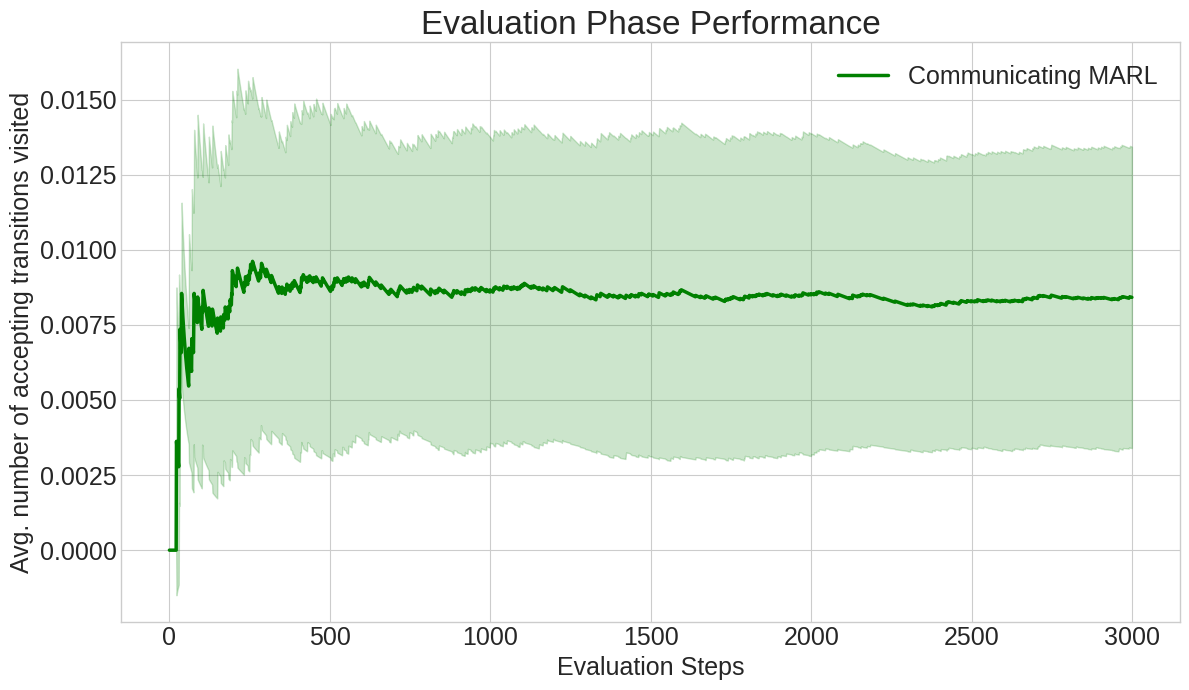

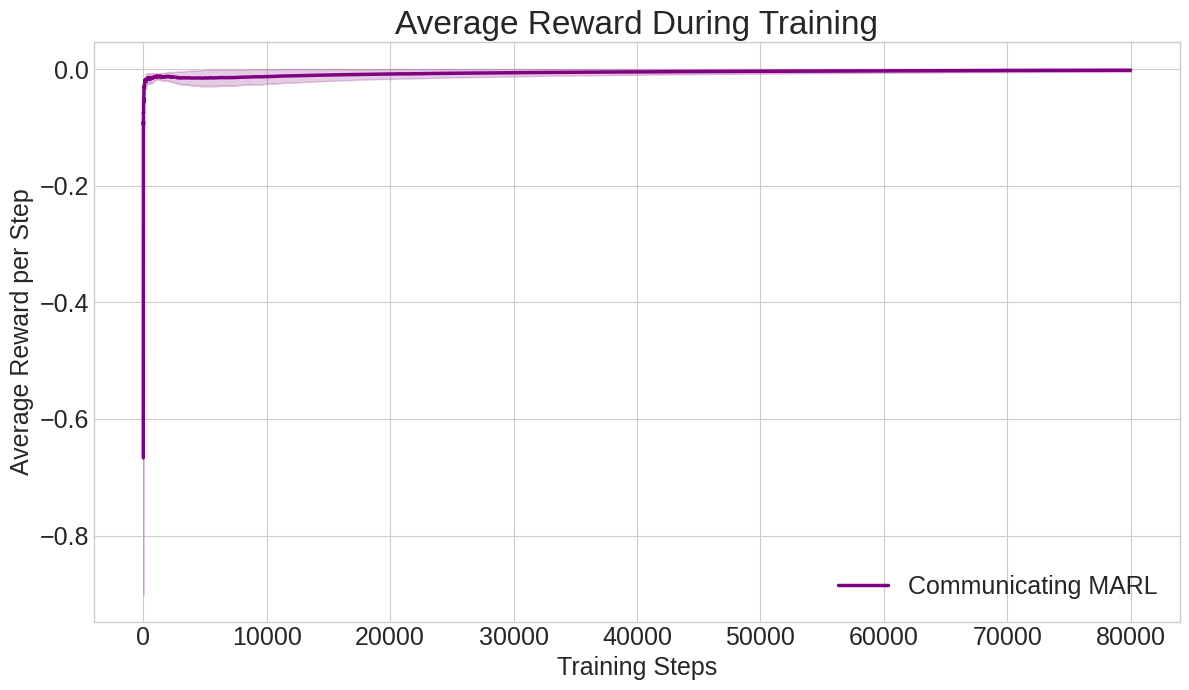

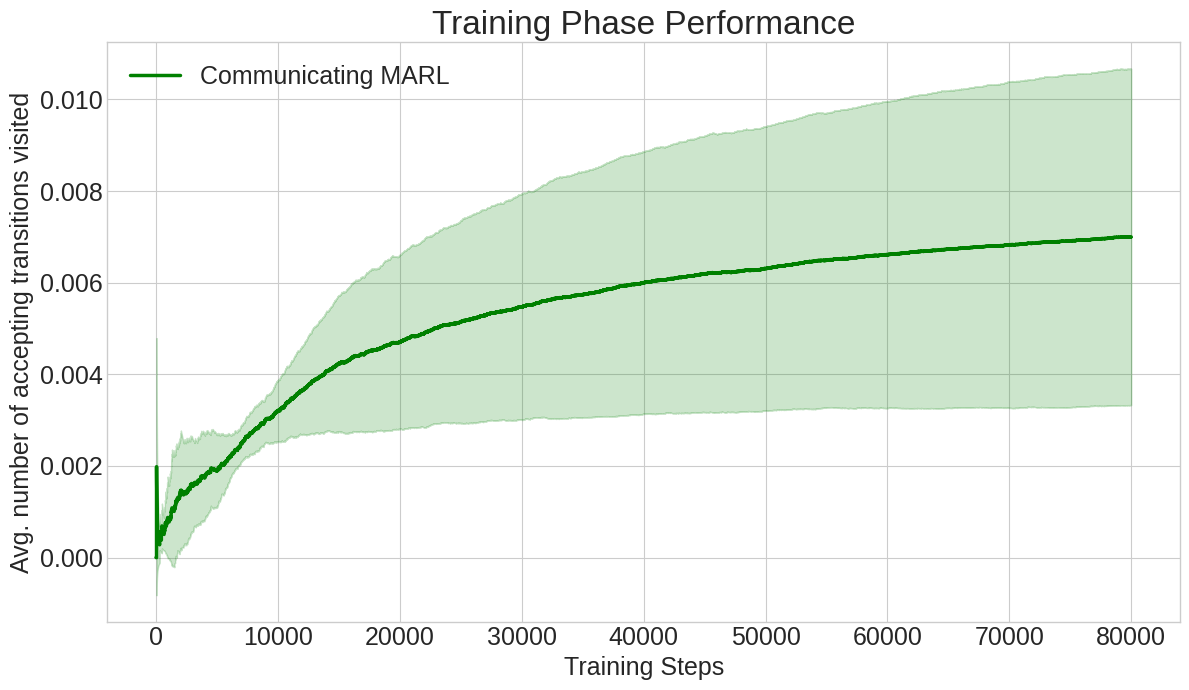

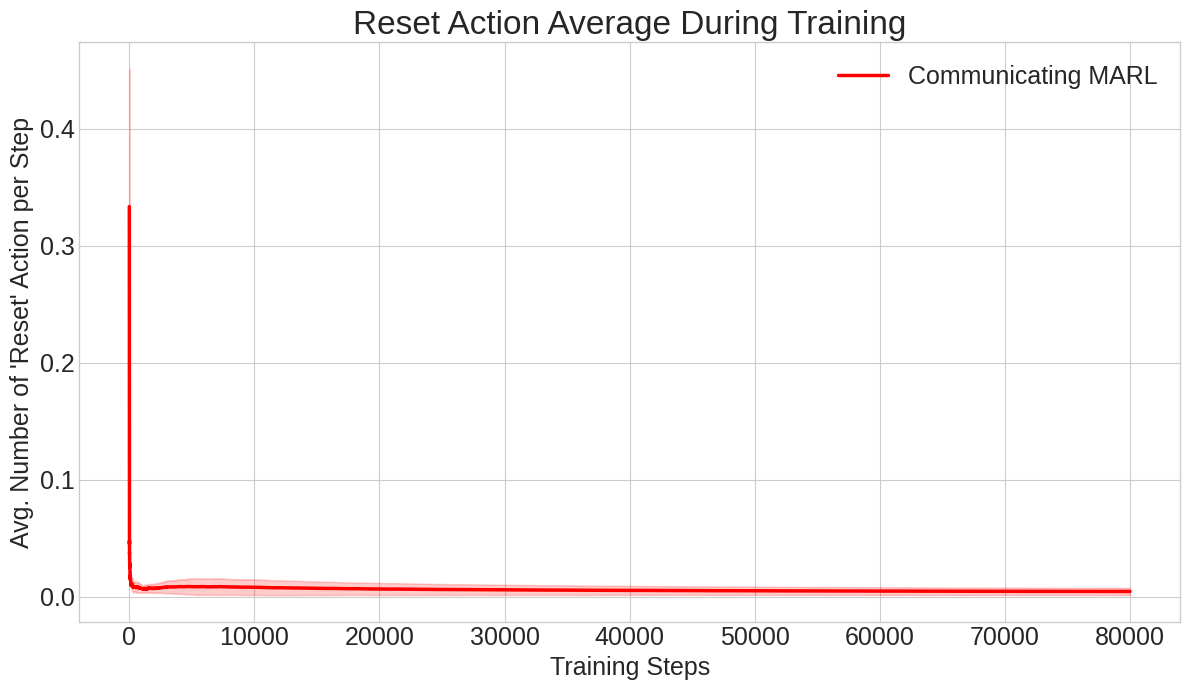


Generating Outer Loop Evaluation Performance plot...


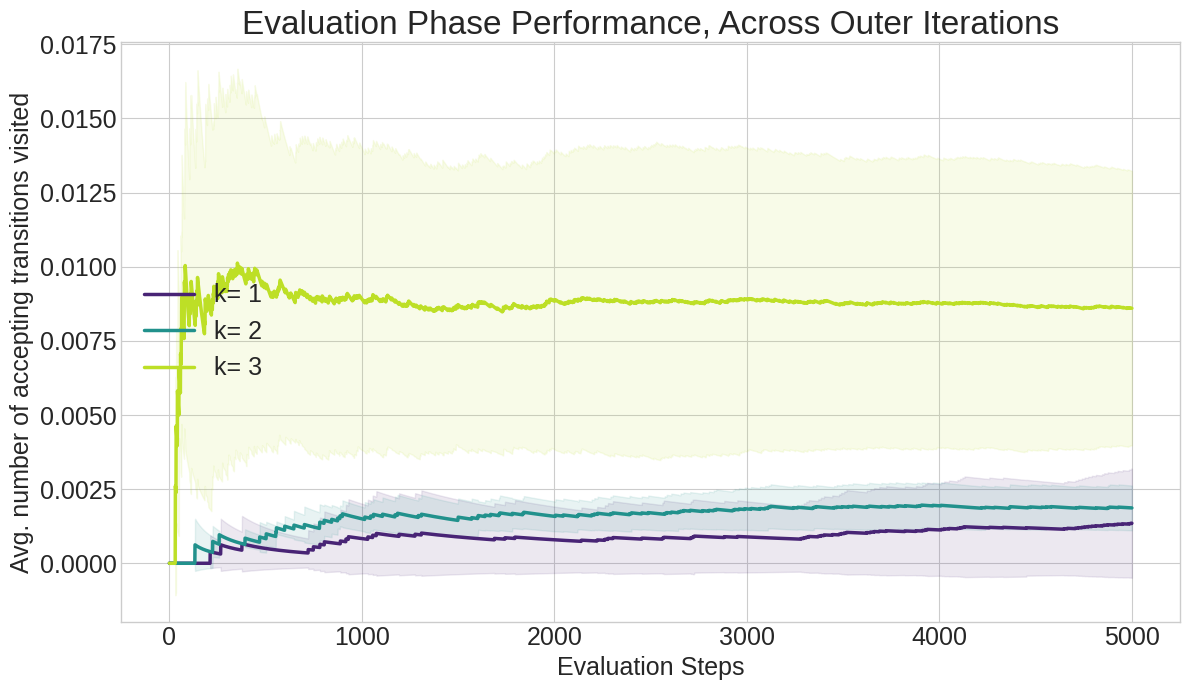



--- Final Evaluation Summary ---
Seeds: [5, 20, 24]
Mode: Communicating MARL
------------------------------------------------
Mean Total Satisfactions: 101.00 ± 60.20
------------------------------------------------

--- Evaluating fixed penalty c=-1, SEED 5 ---
Fixed-penalty evaluation complete for c=-1, SEED 5. Total satisfactions: 42

--- Evaluating fixed penalty c=-1, SEED 20 ---
Fixed-penalty evaluation complete for c=-1, SEED 20. Total satisfactions: 52

--- Evaluating fixed penalty c=-1, SEED 24 ---
Fixed-penalty evaluation complete for c=-1, SEED 24. Total satisfactions: 38

--- Evaluating fixed penalty c=-5, SEED 5 ---
Fixed-penalty evaluation complete for c=-5, SEED 5. Total satisfactions: 111

--- Evaluating fixed penalty c=-5, SEED 20 ---
Fixed-penalty evaluation complete for c=-5, SEED 20. Total satisfactions: 28

--- Evaluating fixed penalty c=-5, SEED 24 ---
Fixed-penalty evaluation complete for c=-5, SEED 24. Total satisfactions: 107

--- Evaluating fixed penalty c=-1

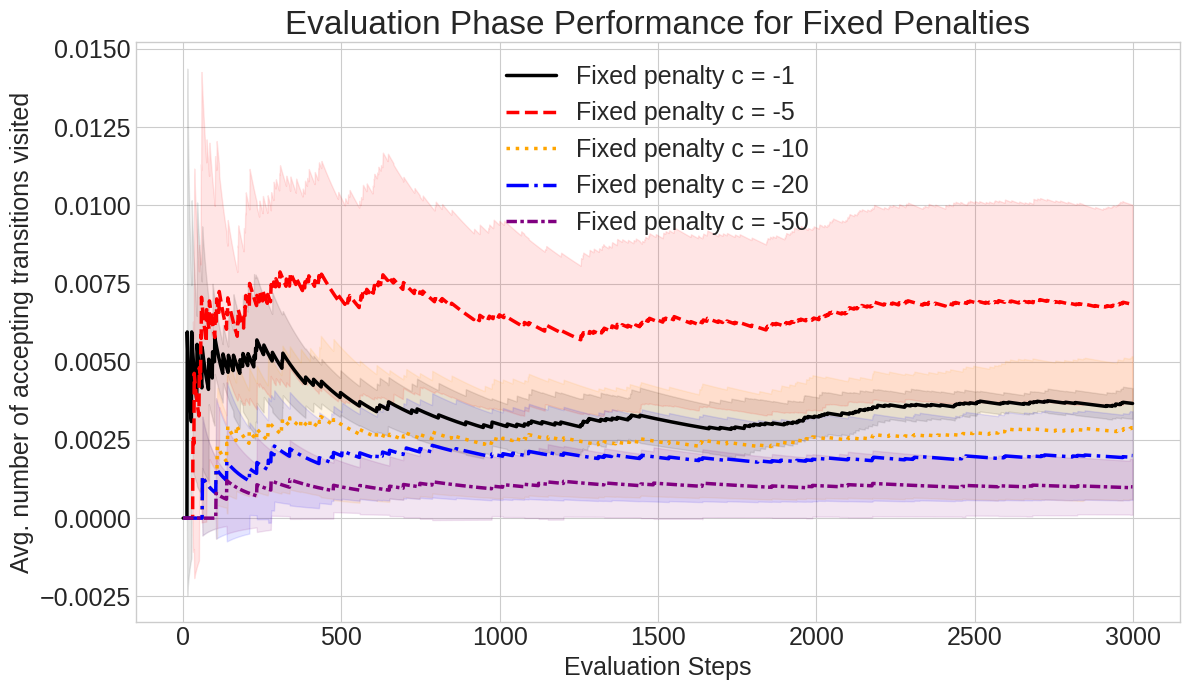

Saved: plot_fixed_penalty_evaluation_performance.png


In [3]:
# @title
# Code 2: Visualization for communicating MARL

ALL_SEEDS = [5, 20, 24]
NUM_SEEDS = len(ALL_SEEDS)
MODE = 'communicating'

import numpy as np
import pickle
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import random
import math

try:
    import pettingzoo
    from pettingzoo.utils import parallel_to_aec, aec_to_parallel
    from pettingzoo.test import parallel_api_test
    import pygame
    from gymnasium import spaces
    from IPython.display import display, Image
    import imageio
    import os
    os.environ["SDL_VIDEODRIVER"] = "dummy"
except ImportError:
    print("Installing PettingZoo, Pygame, and imageio...")
    !pip install pettingzoo[classic] pygame imageio gymnasium > /dev/null 2>&1
    import pettingzoo
    from pettingzoo.utils import parallel_to_aec, aec_to_parallel
    from pettingzoo.test import parallel_api_test
    import pygame
    from gymnasium import spaces
    from IPython.display import display, Image
    import imageio
    import os
    os.environ["SDL_VIDEODRIVER"] = "dummy"
    print("Installation complete.")


# -----------------------------
# Grid World Configuration
# -----------------------------
NUM_AGENTS = 4
GRID_ROWS = 6
GRID_COLS = 6
NUM_CELLS = GRID_ROWS * GRID_COLS

AGENT_ACTIONS = {
    'UP': 0,
    'DOWN': 1,
    'LEFT': 2,
    'RIGHT': 3,
    'STAY': 4,
    'RESET_RM_STAY': 5
}
NUM_ACTIONS_PER_AGENT = len(AGENT_ACTIONS)

ACTION_EFFECTS = {
    AGENT_ACTIONS['UP']: (-1, 0),
    AGENT_ACTIONS['DOWN']: (1, 0),
    AGENT_ACTIONS['LEFT']: (0, -1),
    AGENT_ACTIONS['RIGHT']: (0, 1),
    AGENT_ACTIONS['STAY']: (0, 0),
    AGENT_ACTIONS['RESET_RM_STAY']: (0, 0)
}

NUM_JOINT_ACTIONS = NUM_ACTIONS_PER_AGENT ** NUM_AGENTS


def get_flat_pos(row, col):
    return row * GRID_COLS + col


def get_row_col(flat_pos):
    return flat_pos // GRID_COLS, flat_pos % GRID_COLS


START_POSITIONS_LIST = [21, 15, 14, 20]

AGENT_RCH1_CELLS = {
    0: 0,
    1: 30,
    2: 35,
    3: 5,
}

AGENT_RCH2_CELLS = {
    0: 5,
    1: 0,
    2: 30,
    3: 35,
}

SAFE_TARGET_CELLS = set(AGENT_RCH1_CELLS.values()) | set(AGENT_RCH2_CELLS.values())


def get_manhattan_distance(pos1_flat, pos2_flat):
    r1, c1 = get_row_col(pos1_flat)
    r2, c2 = get_row_col(pos2_flat)
    return abs(r1 - r2) + abs(c1 - c2)


def decode_env_state(env_state_idx):
    positions = []
    temp_idx = env_state_idx

    for _ in range(NUM_AGENTS):
        positions.append(temp_idx % NUM_CELLS)
        temp_idx //= NUM_CELLS

    return positions[::-1]


def encode_env_state(positions_list):
    env_state_idx = 0

    for pos in positions_list:
        env_state_idx = env_state_idx * NUM_CELLS + pos

    return env_state_idx


def decode_joint_action(joint_action_idx):
    actions = []
    temp_idx = joint_action_idx

    for _ in range(NUM_AGENTS):
        actions.append(temp_idx % NUM_ACTIONS_PER_AGENT)
        temp_idx //= NUM_ACTIONS_PER_AGENT

    return actions[::-1]


def get_next_cell_pos(current_flat_pos, action_idx):
    r_curr, c_curr = get_row_col(current_flat_pos)
    dr, dc = ACTION_EFFECTS.get(action_idx, (0, 0))

    r_next, c_next = r_curr + dr, c_curr + dc

    if not (0 <= r_next < GRID_ROWS and 0 <= c_next < GRID_COLS):
        return current_flat_pos

    return get_flat_pos(r_next, c_next)


def get_non_colliding_initial_state():
    return encode_env_state(START_POSITIONS_LIST)


# -----------------------------
# State Feature Engineering
# -----------------------------
RM_STATES = None
RM_STATE_MAP = None
NUM_RM_STATES = None


def get_state_features(env_state_idx, agent_index, rm_state):
    all_positions = decode_env_state(env_state_idx)
    my_pos = all_positions[agent_index]
    other_positions = [pos for i, pos in enumerate(all_positions) if i != agent_index]

    features = []
    my_r, my_c = get_row_col(my_pos)
    max_dist = (GRID_ROWS - 1) + (GRID_COLS - 1)

    features.extend([my_r / (GRID_ROWS - 1), my_c / (GRID_COLS - 1)])

    for pos_flat in other_positions:
        r, c = get_row_col(pos_flat)
        features.extend([r / (GRID_ROWS - 1), c / (GRID_COLS - 1)])

    dist_to_rch1 = get_manhattan_distance(my_pos, AGENT_RCH1_CELLS[agent_index])
    dist_to_rch2 = get_manhattan_distance(my_pos, AGENT_RCH2_CELLS[agent_index])

    features.append(dist_to_rch1 / max_dist if max_dist > 0 else 0)
    features.append(dist_to_rch2 / max_dist if max_dist > 0 else 0)

    for other_pos in other_positions:
        dist_to_other = get_manhattan_distance(my_pos, other_pos)
        features.append(dist_to_other / max_dist if max_dist > 0 else 0)

    is_on_edge = (
        my_r == 0 or
        my_r == GRID_ROWS - 1 or
        my_c == 0 or
        my_c == GRID_COLS - 1
    )

    is_in_corner = (
        (my_r == 0 or my_r == GRID_ROWS - 1) and
        (my_c == 0 or my_c == GRID_COLS - 1)
    )

    features.extend([1.0 if is_on_edge else 0.0, 1.0 if is_in_corner else 0.0])

    rm_state_one_hot = np.zeros(NUM_RM_STATES)
    if rm_state in RM_STATE_MAP:
        rm_state_one_hot[RM_STATE_MAP[rm_state]] = 1.0

    features.extend(rm_state_one_hot)
    features.append(1.0)

    return np.array(features)


# -----------------------------
# Probabilistic Actions and Collision Avoidance
# -----------------------------
PROBABILISTIC_ACTION_CONFIG = {
    AGENT_ACTIONS['UP']: [
        (AGENT_ACTIONS['UP'], 0.8),
        (AGENT_ACTIONS['LEFT'], 0.1),
        (AGENT_ACTIONS['RIGHT'], 0.1)
    ],
    AGENT_ACTIONS['DOWN']: [
        (AGENT_ACTIONS['DOWN'], 0.8),
        (AGENT_ACTIONS['LEFT'], 0.1),
        (AGENT_ACTIONS['RIGHT'], 0.1)
    ],
    AGENT_ACTIONS['LEFT']: [
        (AGENT_ACTIONS['LEFT'], 0.8),
        (AGENT_ACTIONS['UP'], 0.1),
        (AGENT_ACTIONS['DOWN'], 0.1)
    ],
    AGENT_ACTIONS['RIGHT']: [
        (AGENT_ACTIONS['RIGHT'], 0.8),
        (AGENT_ACTIONS['UP'], 0.1),
        (AGENT_ACTIONS['DOWN'], 0.1)
    ],
    AGENT_ACTIONS['STAY']: [
        (AGENT_ACTIONS['STAY'], 1.0)
    ],
    AGENT_ACTIONS['RESET_RM_STAY']: [
        (AGENT_ACTIONS['RESET_RM_STAY'], 1.0)
    ]
}


def get_probabilistic_outcomes(action_idx):
    return PROBABILISTIC_ACTION_CONFIG.get(action_idx, [(action_idx, 1.0)])


def _calculate_next_state_with_collision_avoidance(current_s_idx, actual_actions):
    current_positions = decode_env_state(current_s_idx)

    potential_next_positions = [
        get_next_cell_pos(current_positions[i], actual_actions[i])
        for i in range(NUM_AGENTS)
    ]

    final_positions = list(current_positions)
    agent_indices = list(range(NUM_AGENTS))
    colliding_agents = set()

    for i in agent_indices:
        if i in colliding_agents:
            continue

        for j in range(i + 1, NUM_AGENTS):
            if j in colliding_agents:
                continue

            if potential_next_positions[i] == potential_next_positions[j]:
                destination_cell = potential_next_positions[i]

                if destination_cell not in SAFE_TARGET_CELLS:
                    colliding_agents.add(i)
                    colliding_agents.add(j)

    for i in agent_indices:
        if i not in colliding_agents:
            final_positions[i] = potential_next_positions[i]

    return encode_env_state(final_positions)


def get_label(env_state_idx, agent_index):
    positions = decode_env_state(env_state_idx)

    is_rch1 = (positions[agent_index] == AGENT_RCH1_CELLS[agent_index])
    is_rch2 = (positions[agent_index] == AGENT_RCH2_CELLS[agent_index])

    rch1_str = "(rch1)" if is_rch1 else "(!rch1)"
    rch2_str = "(rch2)" if is_rch2 else "(!rch2)"

    return f"{rch1_str}&{rch2_str}"


# -----------------------------
# Reward Machine and Softmax
# -----------------------------
class RewardMachine:
    def __init__(self, initial_state, states, transitions):
        self.initial_state = initial_state
        self.states = states
        self.transitions = {
            key: (value[0][0], int(value[0][1]))
            for key, value in transitions.items()
        }

    def step(self, current_rm_state, symbol):
        return self.transitions.get(
            (current_rm_state, symbol),
            (current_rm_state, 0.0)
        )


def softmax(x):
    exp_x = np.exp(x - np.max(x, axis=-1, keepdims=True))
    return exp_x / np.sum(exp_x, axis=-1, keepdims=True)


# -----------------------------
# PettingZoo Environment
# -----------------------------
class GridWorldEnv(pettingzoo.ParallelEnv):
    metadata = {
        "render_modes": ["rgb_array"],
        "name": "gridworld-v0"
    }

    def __init__(self, render_mode="rgb_array"):
        self.agents = [f"agent_{i+1}" for i in range(NUM_AGENTS)]
        self.possible_agents = self.agents[:]
        self.render_mode = render_mode

        self.num_env_states = NUM_CELLS ** NUM_AGENTS
        self.current_env_state = 0

        self.observation_space = {
            a: spaces.Discrete(self.num_env_states)
            for a in self.agents
        }

        self.action_space = {
            a: spaces.Discrete(NUM_ACTIONS_PER_AGENT)
            for a in self.agents
        }

        self.screen_width = 400
        self.screen_height = 400
        self.screen = None

        colors = [
            plt.cm.viridis(i / max(1, NUM_AGENTS - 1))
            for i in range(NUM_AGENTS)
        ]

        self.agent_colors = [
            (int(r * 255), int(g * 255), int(b * 255))
            for r, g, b, a in colors
        ]

    def reset(self, seed=None, options=None):
        if seed is not None:
            np.random.seed(seed)
            random.seed(seed)

        self.current_env_state = get_non_colliding_initial_state()
        return self._get_obs(), {a: {} for a in self.agents}

    def _get_obs(self):
        return {a: self.current_env_state for a in self.agents}

    def step(self, actions):
        actual_actions = []

        for i, agent_id in enumerate(self.agents):
            policy_action = actions[agent_id]
            outcomes = get_probabilistic_outcomes(policy_action)
            action_choices, probs = zip(*outcomes)
            actual_actions.append(np.random.choice(action_choices, p=probs))

        self.current_env_state = _calculate_next_state_with_collision_avoidance(
            self.current_env_state,
            actual_actions
        )

        return (
            self._get_obs(),
            {a: 0 for a in self.agents},
            {a: False for a in self.agents},
            {a: False for a in self.agents},
            {a: {} for a in self.agents}
        )

    def render(self):
        if self.screen is None:
            pygame.init()
            self.screen = pygame.Surface((self.screen_width, self.screen_height))

        cell_w = self.screen_width / GRID_COLS
        cell_h = self.screen_height / GRID_ROWS

        self.screen.fill((255, 255, 255))

        indicator_w = cell_w / 2
        indicator_h = cell_h / 2

        quadrant_offsets = [
            (0, 0),
            (indicator_w, 0),
            (0, indicator_h),
            (indicator_w, indicator_h)
        ]

        for i in range(NUM_AGENTS):
            agent_color = self.agent_colors[i]
            offset_x, offset_y = quadrant_offsets[i]

            rch1_flat = AGENT_RCH1_CELLS[i]
            r1, c1 = get_row_col(rch1_flat)

            rch1_color = (
                min(255, agent_color[0] + 120),
                min(255, agent_color[1] + 120),
                min(255, agent_color[2] + 120)
            )

            indicator_x1 = c1 * cell_w + offset_x
            indicator_y1 = r1 * cell_h + offset_y

            pygame.draw.rect(
                self.screen,
                rch1_color,
                (indicator_x1, indicator_y1, indicator_w, indicator_h)
            )

            rch2_flat = AGENT_RCH2_CELLS[i]
            r2, c2 = get_row_col(rch2_flat)
            rch2_color = agent_color

            indicator_x2 = c2 * cell_w + offset_x
            indicator_y2 = r2 * cell_h + offset_y

            pygame.draw.rect(
                self.screen,
                rch2_color,
                (indicator_x2, indicator_y2, indicator_w, indicator_h)
            )

        for r in range(GRID_ROWS):
            for c in range(GRID_COLS):
                pygame.draw.rect(
                    self.screen,
                    (128, 128, 128),
                    (c * cell_w, r * cell_h, cell_w, cell_h),
                    1
                )

        for i, pos_flat in enumerate(decode_env_state(self.current_env_state)):
            r, c = get_row_col(pos_flat)

            pygame.draw.circle(
                self.screen,
                self.agent_colors[i],
                (c * cell_w + cell_w / 2, r * cell_h + cell_h / 2),
                min(cell_w, cell_h) / 3
            )

        if self.render_mode == "rgb_array":
            return np.transpose(
                np.array(pygame.surfarray.pixels3d(self.screen)),
                axes=(1, 0, 2)
            )

    def close(self):
        if self.screen:
            pygame.quit()
            self.screen = None



def _convert_outer_history_to_float(raw):
    """
    Converts saved outer_eval_accept_histories into a numeric float array
    with shape:
        (number_of_outer_iterations, H_k)
    """
    raw = np.asarray(raw)

    if raw.ndim == 0:
        raw = raw.item()
        raw = np.asarray(raw)

    if raw.size == 0:
        return np.empty((0, 0), dtype=np.float64)

    if raw.dtype == object:
        if raw.ndim == 1:
            first = raw[0]

            # Case: a single 1D history stored directly
            if np.isscalar(first):
                return np.asarray(raw, dtype=np.float64).reshape(1, -1)

            # Case: multiple histories stored as object rows/lists
            return np.asarray(
                [np.asarray(x, dtype=np.float64) for x in raw],
                dtype=np.float64
            )
        else:
            # Case: 2D object array
            return np.asarray(raw.tolist(), dtype=np.float64)

    else:
        arr = np.asarray(raw, dtype=np.float64)

        if arr.ndim == 1:
            arr = arr.reshape(1, -1)

        return arr


# -----------------------------
# Visualization Function for Adaptive Algorithm 2
# -----------------------------
def visualize():
    global RM_STATES, RM_STATE_MAP, NUM_RM_STATES

    num_agents = NUM_AGENTS

    training_rewards = []
    training_satisfactions = []
    reset_action_counts = []
    eval_satisfactions = []
    outer_eval_accept_histories_all_seeds = []

    steps_history = None
    eval_steps_history = None

    last_run_results = None
    last_run_eval_frames = []

    for i, seed in enumerate(ALL_SEEDS):
        seed_index = i + 1

        print(f"\n--- Loading and Processing for SEED {seed_index} ---")

        try:
            results_file = f'training_results_{MODE}_seed_{seed}.npz'
            rm_file = f'reward_machine_{MODE}_seed_{seed}.pkl'

            results = np.load(results_file, allow_pickle=True)

            with open(rm_file, 'rb') as f:
                rm = pickle.load(f)

        except FileNotFoundError:
            print(f"Error: '{results_file}' or '{rm_file}' not found.")
            print("Please run Code 1 first to generate these files.")
            return

        except Exception as e:
            print(f"Error loading files for seed {seed}: {e}")
            return

        training_rewards.append(results['overall_average_reward_history'])
        training_satisfactions.append(results['successful_satisfactions_history'])
        reset_action_counts.append(results['reset_action_counts_history'])

        if 'outer_eval_accept_histories' in results.files:
            outer_hist_seed = _convert_outer_history_to_float(
                results['outer_eval_accept_histories']
            )
            outer_eval_accept_histories_all_seeds.append(outer_hist_seed)
        else:
            print(
                f"Warning: 'outer_eval_accept_histories' not found for seed {seed}. "
                f"Outer-loop plot will be skipped for this seed."
            )
            outer_eval_accept_histories_all_seeds.append(
                np.empty((0, 0), dtype=np.float64)
            )

        if steps_history is None:
            steps_history = results['steps_history']

        RM_STATES = sorted(list(rm.states))
        RM_STATE_MAP = {state: i for i, state in enumerate(RM_STATES)}
        NUM_RM_STATES = len(RM_STATES)

        print(f"  Running evaluation for SEED {seed_index}...")

        num_evaluation_steps = 3000 #10000
        env = GridWorldEnv()
        obs, _ = env.reset(seed=seed + 1)

        evaluation_frames = []
        num_eval_animation_steps = 1000

        eval_satis_count = 0
        current_eval_steps_history = []
        current_eval_satisfactions_history = []

        evaluation_temperature = 0.9

        actor_weights = results['actor_weights']
        eval_rm_states = [rm.initial_state for _ in range(num_agents)]

        for step in range(num_evaluation_steps):
            if seed_index == NUM_SEEDS and step < num_eval_animation_steps:
                evaluation_frames.append(env.render())

            actions_dict = {}
            current_s_idx = obs["agent_1"]

            for i_agent in range(num_agents):
                agent_id_str = f"agent_{i_agent+1}"

                features = get_state_features(
                    current_s_idx,
                    i_agent,
                    eval_rm_states[i_agent]
                )

                logits = np.dot(features, actor_weights[i_agent])
                temp_adjusted_logits = logits / evaluation_temperature
                action_probabilities = softmax(temp_adjusted_logits)

                actions_dict[agent_id_str] = np.random.choice(
                    NUM_ACTIONS_PER_AGENT,
                    p=action_probabilities
                )

            obs, _, _, _, _ = env.step(actions_dict)
            next_s_idx = obs["agent_1"]

            labels = [
                get_label(next_s_idx, i_agent)
                for i_agent in range(num_agents)
            ]

            temp_next_rm_states = list(eval_rm_states)

            for i_agent in range(num_agents):
                agent_id_str = f"agent_{i_agent+1}"

                if actions_dict[agent_id_str] == AGENT_ACTIONS['RESET_RM_STAY']:
                    temp_next_rm_states[i_agent] = rm.initial_state
                else:
                    next_rm, r = rm.step(eval_rm_states[i_agent], labels[i_agent])
                    temp_next_rm_states[i_agent] = next_rm

                    if r > 0:
                        eval_satis_count += 1

            eval_rm_states = temp_next_rm_states

            current_eval_steps_history.append(step)
            current_eval_satisfactions_history.append(eval_satis_count)

        env.close()

        eval_satisfactions.append(current_eval_satisfactions_history)

        if eval_steps_history is None:
            eval_steps_history = current_eval_steps_history

        print(
            f"  Evaluation complete for SEED {seed_index}. "
            f"Total Satisfactions: {eval_satis_count}"
        )

        if seed_index == NUM_SEEDS:
            last_run_results = results
            last_run_eval_frames = evaluation_frames

    print("\nAll seeds processed. Calculating statistics...")

    step_counts_train = np.array(steps_history) + 1
    step_counts_eval = np.array(eval_steps_history) + 1

    all_tr_rewards_np = np.array(training_rewards)
    mean_tr_reward = np.mean(all_tr_rewards_np, axis=0)
    std_tr_reward = np.std(all_tr_rewards_np, axis=0)

    all_tr_satis_np = np.array(training_satisfactions)
    all_tr_satis_rate_np = all_tr_satis_np / step_counts_train / num_agents
    mean_tr_satis_rate = np.mean(all_tr_satis_rate_np, axis=0)
    std_tr_satis_rate = np.std(all_tr_satis_rate_np, axis=0)

    all_eval_satis_np = np.array(eval_satisfactions)
    all_eval_satis_rate_np = all_eval_satis_np / step_counts_eval / num_agents
    mean_eval_satis_rate = np.mean(all_eval_satis_rate_np, axis=0)
    std_eval_satis_rate = np.std(all_eval_satis_rate_np, axis=0)

    all_reset_counts_np = np.array(reset_action_counts)
    all_reset_rate_np = all_reset_counts_np / step_counts_train / num_agents
    mean_reset_rate = np.mean(all_reset_rate_np, axis=0)
    std_reset_rate = np.std(all_reset_rate_np, axis=0)

    final_eval_satisfactions = [run[-1] for run in all_eval_satis_np]
    mean_final_eval_satis = np.mean(final_eval_satisfactions)
    std_final_eval_satis = np.std(final_eval_satisfactions)


    print(f"\nSaving animations from last run (SEED {ALL_SEEDS[-1]})...")

    try:
        if (
            'training_frames' in last_run_results and
            last_run_results['training_frames'].size > 0
        ):
            print("Saving training_animation.gif...")
            imageio.mimsave(
                'training_animation.gif',
                last_run_results['training_frames'],
                fps=20
            )

        if last_run_eval_frames:
            print("Saving trained_agent_animation.gif...")
            imageio.mimsave(
                'trained_agent_animation.gif',
                last_run_eval_frames,
                fps=30
            )

    except Exception as e:
        print(f"Error saving animations: {e}")

    # -----------------------------
    # Plotting
    # -----------------------------
    print("\nGenerating communicating-only performance plots...")

    plt.style.use('seaborn-v0_8-whitegrid')

    FONTSIZE_TITLE = 24
    FONTSIZE_LABEL = 18
    FONTSIZE_LEGEND = 18
    FONTSIZE_TICKS = 18


    plt.figure(figsize=(12, 7))
    plt.plot(
        eval_steps_history,
        mean_eval_satis_rate,
        label='Communicating MARL',
        color='green',
        linewidth=2.5
    )
    plt.fill_between(
        eval_steps_history,
        mean_eval_satis_rate - std_eval_satis_rate,
        mean_eval_satis_rate + std_eval_satis_rate,
        color='green',
        alpha=0.2
    )

    plt.title("Evaluation Phase Performance", fontsize=FONTSIZE_TITLE)
    plt.xlabel("Evaluation Steps", fontsize=FONTSIZE_LABEL)
    plt.ylabel(
        "Avg. number of accepting transitions visited",
        fontsize=FONTSIZE_LABEL
    )
    plt.xticks(fontsize=FONTSIZE_TICKS)
    plt.yticks(fontsize=FONTSIZE_TICKS)
    plt.legend(fontsize=FONTSIZE_LEGEND)
    plt.tight_layout()
    plt.savefig("plot_evaluation_performance.png")
    plt.show()


    plt.figure(figsize=(12, 7))
    plt.plot(
        steps_history,
        mean_tr_reward,
        label='Communicating MARL',
        color='purple',
        linewidth=2.5
    )
    plt.fill_between(
        steps_history,
        mean_tr_reward - std_tr_reward,
        mean_tr_reward + std_tr_reward,
        color='purple',
        alpha=0.2
    )

    plt.title("Average Reward During Training", fontsize=FONTSIZE_TITLE)
    plt.xlabel("Training Steps", fontsize=FONTSIZE_LABEL)
    plt.ylabel("Average Reward per Step", fontsize=FONTSIZE_LABEL)
    plt.xticks(fontsize=FONTSIZE_TICKS)
    plt.yticks(fontsize=FONTSIZE_TICKS)
    plt.legend(fontsize=FONTSIZE_LEGEND)
    plt.tight_layout()
    plt.savefig("plot_training_reward.png")
    plt.show()


    plt.figure(figsize=(12, 7))
    plt.plot(
        steps_history,
        mean_tr_satis_rate,
        label='Communicating MARL',
        color='green',
        linewidth=2.5
    )
    plt.fill_between(
        steps_history,
        mean_tr_satis_rate - std_tr_satis_rate,
        mean_tr_satis_rate + std_tr_satis_rate,
        color='green',
        alpha=0.2
    )

    plt.title("Training Phase Performance", fontsize=FONTSIZE_TITLE)
    plt.xlabel("Training Steps", fontsize=FONTSIZE_LABEL)
    plt.ylabel(
        "Avg. number of accepting transitions visited",
        fontsize=FONTSIZE_LABEL
    )
    plt.xticks(fontsize=FONTSIZE_TICKS)
    plt.yticks(fontsize=FONTSIZE_TICKS)
    plt.legend(fontsize=FONTSIZE_LEGEND)
    plt.tight_layout()
    plt.savefig("plot_training_satisfactions.png")
    plt.show()


    plt.figure(figsize=(12, 7))
    plt.plot(
        steps_history,
        mean_reset_rate,
        label='Communicating MARL',
        color='red',
        linewidth=2.5
    )
    plt.fill_between(
        steps_history,
        mean_reset_rate - std_reset_rate,
        mean_reset_rate + std_reset_rate,
        color='red',
        alpha=0.2
    )

    plt.title("Reset Action Average During Training", fontsize=FONTSIZE_TITLE)
    plt.xlabel("Training Steps", fontsize=FONTSIZE_LABEL)
    plt.ylabel(
        "Avg. Number of 'Reset' Action per Step",
        fontsize=FONTSIZE_LABEL
    )
    plt.xticks(fontsize=FONTSIZE_TICKS)
    plt.yticks(fontsize=FONTSIZE_TICKS)
    plt.legend(fontsize=FONTSIZE_LEGEND)
    plt.tight_layout()
    plt.savefig("plot_training_reset_rate.png")
    plt.show()


    print("\nGenerating Outer Loop Evaluation Performance plot...")

    valid_outer_histories = [
        hist for hist in outer_eval_accept_histories_all_seeds
        if hist.ndim == 2 and hist.size > 0
    ]

    if len(valid_outer_histories) == 0:
        print("No valid outer-loop evaluation histories found. Skipping outer-loop plot.")
    else:

        H_k_actual = min(hist.shape[1] for hist in valid_outer_histories)

        valid_outer_histories = [
            hist[:, :H_k_actual]
            for hist in valid_outer_histories
        ]


        max_k = max(hist.shape[0] for hist in valid_outer_histories)

        padded_histories = []

        for hist in valid_outer_histories:
            if hist.shape[0] < max_k:
                pad_rows = max_k - hist.shape[0]
                last_row = hist[-1:]
                padding = np.repeat(last_row, pad_rows, axis=0)
                hist = np.vstack((hist, padding))

            padded_histories.append(hist)


        padded_histories_np = np.stack(padded_histories, axis=0).astype(np.float64)

        step_counts_eval_k = np.arange(1, H_k_actual + 1, dtype=np.float64)


        rates_np = (
            padded_histories_np
            / step_counts_eval_k[None, None, :]
            / float(num_agents)
        )

        mean_rates = np.mean(rates_np, axis=0)
        std_rates = np.std(rates_np, axis=0)

        plt.figure(figsize=(12, 7))

        cmap = plt.cm.viridis
        colors_k = cmap(np.linspace(0.1, 0.9, max_k))

        for k_idx in range(max_k):
            plt.plot(
                step_counts_eval_k,
                mean_rates[k_idx],
                label=f'k= {k_idx+1}',
                color=colors_k[k_idx],
                linewidth=2.5
            )

            plt.fill_between(
                step_counts_eval_k,
                mean_rates[k_idx] - std_rates[k_idx],
                mean_rates[k_idx] + std_rates[k_idx],
                color=colors_k[k_idx],
                alpha=0.1
            )

        plt.title(
            "Evaluation Phase Performance, Across Outer Iterations",
            fontsize=FONTSIZE_TITLE
        )
        plt.xlabel("Evaluation Steps", fontsize=FONTSIZE_LABEL)
        plt.ylabel(
            "Avg. number of accepting transitions visited",
            fontsize=FONTSIZE_LABEL
        )
        plt.xticks(fontsize=FONTSIZE_TICKS)
        plt.yticks(fontsize=FONTSIZE_TICKS)
        plt.legend(
            fontsize=FONTSIZE_LEGEND,

        )
        plt.tight_layout()
        plt.savefig("plot_outer_loop_eval_performance.png")
        plt.show()


    print("\n")
    print("--- Final Evaluation Summary ---")
    print(f"Seeds: {ALL_SEEDS}")
    print("Mode: Communicating MARL")
    print("------------------------------------------------")
    print(
        f"Mean Total Satisfactions: {mean_final_eval_satis:.2f} "
        f"± {std_final_eval_satis:.2f}"
    )
    print("------------------------------------------------")


# -----------------------------
# Fixed Conservative Penalty Evaluation Figure
# -----------------------------
def visualize_fixed_penalty_comparison():
    """
    Generates a figure similar to 'Evaluation Phase Performance',
    but for fixed conservative penalties trained using Algorithm 1 only.

    Each trajectory corresponds to a different fixed penalty:
        c = -5, -10, -20, -50
    """
    global RM_STATES, RM_STATE_MAP, NUM_RM_STATES

    num_agents = NUM_AGENTS

    fixed_penalties = [-1 ,-5, -10, -20, -50]

    eval_histories_by_penalty = {
        p: [] for p in fixed_penalties
    }

    eval_steps_history_fixed = None

    num_evaluation_steps = 3000 #10000
    evaluation_temperature = 0.9

    for fixed_penalty in fixed_penalties:
        fixed_penalty_tag = str(abs(fixed_penalty)).replace('.', 'p')

        for seed in ALL_SEEDS:
            print(
                f"\n--- Evaluating fixed penalty c={fixed_penalty}, "
                f"SEED {seed} ---"
            )

            results_file = (
                f'training_results_fixed_penalty_{fixed_penalty_tag}'
                f'_seed_{seed}.npz'
            )

            rm_file = (
                f'reward_machine_fixed_penalty_{fixed_penalty_tag}'
                f'_seed_{seed}.pkl'
            )

            try:
                results = np.load(results_file, allow_pickle=True)

                with open(rm_file, 'rb') as f:
                    rm = pickle.load(f)

            except FileNotFoundError:
                print(
                    f"Error: '{results_file}' or '{rm_file}' not found."
                )
                print(
                    "Please run Code 1 first to generate the fixed-penalty files."
                )
                return

            except Exception as e:
                print(
                    f"Error loading fixed-penalty files for "
                    f"c={fixed_penalty}, seed={seed}: {e}"
                )
                return

            RM_STATES = sorted(list(rm.states))
            RM_STATE_MAP = {state: i for i, state in enumerate(RM_STATES)}
            NUM_RM_STATES = len(RM_STATES)

            actor_weights = results['actor_weights']

            env = GridWorldEnv()
            obs, _ = env.reset(seed=seed + 1)

            eval_rm_states = [rm.initial_state for _ in range(num_agents)]

            eval_satis_count = 0
            current_eval_steps_history = []
            current_eval_satisfactions_history = []

            for step in range(num_evaluation_steps):
                actions_dict = {}
                current_s_idx = obs["agent_1"]

                for i_agent in range(num_agents):
                    agent_id_str = f"agent_{i_agent+1}"

                    features = get_state_features(
                        current_s_idx,
                        i_agent,
                        eval_rm_states[i_agent]
                    )

                    logits = np.dot(features, actor_weights[i_agent])
                    temp_adjusted_logits = logits / evaluation_temperature
                    action_probabilities = softmax(temp_adjusted_logits)

                    actions_dict[agent_id_str] = np.random.choice(
                        NUM_ACTIONS_PER_AGENT,
                        p=action_probabilities
                    )

                obs, _, _, _, _ = env.step(actions_dict)
                next_s_idx = obs["agent_1"]

                labels = [
                    get_label(next_s_idx, i_agent)
                    for i_agent in range(num_agents)
                ]

                temp_next_rm_states = list(eval_rm_states)

                for i_agent in range(num_agents):
                    agent_id_str = f"agent_{i_agent+1}"

                    if actions_dict[agent_id_str] == AGENT_ACTIONS['RESET_RM_STAY']:
                        temp_next_rm_states[i_agent] = rm.initial_state
                    else:
                        next_rm, r = rm.step(
                            eval_rm_states[i_agent],
                            labels[i_agent]
                        )

                        temp_next_rm_states[i_agent] = next_rm

                        if r > 0:
                            eval_satis_count += 1

                eval_rm_states = temp_next_rm_states

                current_eval_steps_history.append(step)
                current_eval_satisfactions_history.append(eval_satis_count)

            env.close()

            eval_histories_by_penalty[fixed_penalty].append(
                current_eval_satisfactions_history
            )

            if eval_steps_history_fixed is None:
                eval_steps_history_fixed = current_eval_steps_history

            print(
                f"Fixed-penalty evaluation complete for c={fixed_penalty}, "
                f"SEED {seed}. Total satisfactions: {eval_satis_count}"
            )

    print("\nGenerating fixed-penalty evaluation performance plot...")

    step_counts_eval_fixed = np.array(eval_steps_history_fixed) + 1

    plt.style.use('seaborn-v0_8-whitegrid')

    FONTSIZE_TITLE = 24
    FONTSIZE_LABEL = 18
    FONTSIZE_LEGEND = 18
    FONTSIZE_TICKS = 18

    colors = {
        -1: 'black',
        -5: 'red',
        -10: 'orange',
        -20: 'blue',
        -50: 'purple'
    }

    linestyles = {
        -1: '-',
        -5: '--',
        -10: ':',
        -20: '-.',
        -50: (0, (3, 1, 1, 1))
    }

    plt.figure(figsize=(12, 7))

    for fixed_penalty in fixed_penalties:
        all_eval_satis_np = np.array(eval_histories_by_penalty[fixed_penalty])

        all_eval_satis_rate_np = (
            all_eval_satis_np / step_counts_eval_fixed / num_agents
        )

        mean_eval_satis_rate = np.mean(all_eval_satis_rate_np, axis=0)
        std_eval_satis_rate = np.std(all_eval_satis_rate_np, axis=0)

        plt.plot(
            eval_steps_history_fixed,
            mean_eval_satis_rate,
            label=f'Fixed penalty c = {fixed_penalty}',
            color=colors[fixed_penalty],
            linestyle=linestyles[fixed_penalty],
            linewidth=2.5
        )

        plt.fill_between(
            eval_steps_history_fixed,
            mean_eval_satis_rate - std_eval_satis_rate,
            mean_eval_satis_rate + std_eval_satis_rate,
            color=colors[fixed_penalty],
            alpha=0.1
        )

    plt.title(
        "Evaluation Phase Performance for Fixed Penalties",
        fontsize=FONTSIZE_TITLE
    )

    plt.xlabel(
        "Evaluation Steps",
        fontsize=FONTSIZE_LABEL
    )

    plt.ylabel(
        "Avg. number of accepting transitions visited",
        fontsize=FONTSIZE_LABEL
    )

    plt.xticks(fontsize=FONTSIZE_TICKS)
    plt.yticks(fontsize=FONTSIZE_TICKS)

    plt.legend(
        fontsize=FONTSIZE_LEGEND,

    )

    plt.tight_layout()
    plt.savefig("plot_fixed_penalty_evaluation_performance.png")
    plt.show()

    print("Saved: plot_fixed_penalty_evaluation_performance.png")


visualize()
visualize_fixed_penalty_comparison()